## Plot the generated daily soil and runoff cation concentrations

In [ ]:
import os
import xarray as xr
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

rcParams['font.size'] = 13
rcParams['axes.titlesize'] = 13

In [ ]:
def read_obs_UIEF():
    # Read observations
    path_data = os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data', 'UIEF')

    # (1) Observed percentage cations in soil
    soil_cations = pd.read_excel(os.path.join(path_data, 'pnas.2319436121.sd03.xlsx'),
                                index_col = 1, parse_dates = True)
    soil_cations.index = soil_cations.index.year
    soil_cations = soil_cations.reset_index().set_index(['Sampling Date', 'Block']
        ).drop(['LabID','Total Application (kg/m2)'], axis = 1)
    soil_cations_mean = soil_cations.groupby('Sampling Date').mean()
    soil_cations_std = soil_cations.groupby('Sampling Date').std()

    # (2) Observed percentage cations in basalt
    basalt_cations = pd.read_excel(os.path.join(path_data, 'pnas.2319436121.sd01.xlsx'),
                                header = 0, skiprows = lambda x: x not in [0,5], 
                                index_col = 0).iloc[0, :]

    # (3) Basalt mass in 0-10cm
    basalt_mass = pd.read_excel(os.path.join(path_data, 'pnas.2319436121.sd06.xlsx'),
                                header = 74, index_col = 0, usecols = 'A:H')
    print('Ca percentage (%): ') # compares well with ca_mass below
    print(np.array([1539.0178, 3007.0829, 4408.99, 5749.11]) / basalt_mass['mbasalt0-10cm']
    * 100 / 1e3)
    print('Mg percentage (%): ') # mg_mass below is too high
    print(np.array([1180.064, 2305.724, 3380.657, 4408.217]) / basalt_mass['mbasalt0-10cm']
    * 100 / 1e3)

    # (4) Weathering difference
    weathering_difference = pd.read_excel(os.path.join(path_data, 'pnas.2319436121.sd06.xlsx'),
                                        header = 2, usecols = [0,49,50,52,53],
                                        index_col = 0, 
                                        skiprows = list(range(2)) + list(range(4,34)) + \
                                            list(range(39,80)))
    weathering_difference.columns = ['Ca weathered', 'stdev.1', 'Mg weathered', 'stdev.2']

    # (5) CEC %, extracted from the plot
    cec_pct = {
        ('base sat', '0-10cm' , 'treatment'): [80.35714285714286, 82.94642857142857, 
                                                89.28571428571428, 87.58928571428572, 
                                                82.94642857142857],
        ('base sat', '0-10cm' , 'control'  ): [78.92857142857143, 80.71428571428572, 85, 
                                                78.92857142857143, 72.67857142857143],
        ('base sat', '10-30cm', 'treatment'): [83.125, 79.55357142857143, 80.89285714285714,
                                                80.44642857142857, 86.51785714285714],
        ('base sat', '10-30cm', 'control'  ): [81.07142857142857, 77.14285714285714, 
                                                76.51785714285714, 75.80357142857143, 
                                                82.76785714285714],
        ('acid'    , '0-10cm' , 'control'  ): [20.416666666666668, 19.09722222222222, 
                                            14.722222222222221, 20.694444444444443, 
                                            26.875000000000004],
        ('acid'    , '0-10cm' , 'treatment'): [18.88888888888889, 16.73611111111111,
                                            10.416666666666664, 12.013888888888888, 
                                            16.73611111111111],
        ('acid'    , '10-30cm', 'control'  ): [18.819444444444443, 22.63888888888889,
                                            23.055555555555554, 23.61111111111111, 
                                            16.80555555555555],
        ('acid'    , '10-30cm', 'treatment'): [16.666666666666668, 20.20833333333333, 
                                            18.88888888888889, 19.23611111111111, 13.26388888888889]
    }
    cec_pct = pd.DataFrame(cec_pct, index = range(2016, 2021))

    # (6) Soil pH, extracted from the plot
    obs_soil_pH = {
        ('0-10cm', 'treatment' ): [6.131292517006803, 6.6020408163265305, 
                                6.661904761904761, 6.92312925170068, 6.925850340136054],
        ('0-10cm', 'control'   ): [6.210204081632653, 6.280952380952381,
                                6.313605442176871, 6.134013605442177, 5.97891156462585],
        ('10-30cm', 'treatment'): [6.109523809523809, 6.406122448979592,
                                6.5639455782312925, 6.485034013605442, 6.512244897959183],
        ('10-30cm', 'control'  ): [6.022448979591837, 6.289115646258503,
                                6.316326530612245, 6.131292517006803, 6.245578231292517]
    }
    obs_soil_pH = pd.DataFrame(obs_soil_pH, index = range(2016, 2021))

    return obs_soil_pH, cec_pct, weathering_difference

obs_soil_pH, cec_pct, weathering_difference = read_obs_UIEF()

Ca percentage (%): 
Year
2017    5.307246
2018    5.184907
2019    5.068080
2020    4.956399
Name: mbasalt0-10cm, dtype: float64
Mg percentage (%): 
Year
2017    4.069407
2018    3.975602
2019    3.886024
2020    3.800394
Name: mbasalt0-10cm, dtype: float64


In [3]:
# control - no treatment
#case_name = '20250918_UIEF_ICB20TRCNPRDCTCBC'
case_name = '20250917_UIEF_ICB20TRCNPRDCTCBC'
#case_name = '20250331_UIEF_ICB20TRCNPRDCTCBC_6year_rmethod1_2xCO2'
flist_1 = [os.path.join(os.environ['E3SM_ROOT'], 'output', f'{case_name}_appCtrlerw', 'run', 
                        f'{case_name}_appCtrlerw.elm.h1.{yy}-01-01-00000.nc') \
           #for yy in range(1980, 2016)]
           for yy in range(2015, 2022)]
hr0 = xr.open_mfdataset(flist_1)

# treatment - metabasalt
#case_name = '20250918_UIEF_ICB20TRCNPRDCTCBC_altChem'
case_name = '20250920_UIEF_ICB20TRCNPRDCTCBC_obsForc'
flist_2 = [os.path.join(os.environ['E3SM_ROOT'], 'output', f'{case_name}erw', 'run', 
                        f'{case_name}erw.elm.h1.{yy}-01-01-00000.nc') \
            #for yy in range(1980, 2016)]
            for yy in range(2015, 2022)]
hr = xr.open_mfdataset(flist_2)

In [ ]:
# Global constants
nlevsoi = 10
zsoi = np.array([0., 0.01751282, 0.04509179, 0.09056182, 0.16552924, 0.2891296,
                    0.49291214, 0.82889277, 1.3828311, 2.2961211, 3.8018818])
thickness = np.diff(zsoi)

depth_ranges = [(0., 0.1), (0.1, 0.3)]
depth_names = ['0-10cm', '10-30cm']
tvec = np.arange(2015, 2022)

# Function to obtain UIEF data
def read_sim_UIEF(hr):
    # Two depths
    soil_pH = pd.DataFrame(np.nan, index = tvec, columns = depth_names)
    for i, (min_depth, max_depth) in enumerate(depth_ranges):
        dname = depth_names[i]
        weight = np.where((zsoi[:-1] < max_depth) & (zsoi[1:] > min_depth),
                          np.minimum(thickness, max_depth - zsoi[:-1], zsoi[1:] - min_depth),
                          0)
        soil_pH[dname] = np.nansum(hr['soil_pH'].resample(time = '1YE').mean().values[:,:nlevsoi,0] * \
                                   weight.reshape(1, -1), axis = 1) / np.sum(weight)

    # gC m-2 s-1 => cumulative tCO2 ha-1
    r_sequestration = pd.Series(
        np.cumsum(hr['r_sequestration'].resample(time = '1YE').mean()[:,0].values) * 365 * 24 * 3600 * 44/12 * 0.01,
        index = tvec)

    # CEC: convert from g m-3 soil to meq 100g-1 dry soil
    pct_acid = pd.DataFrame(np.nan, index = tvec, columns = depth_names)
    base_saturation = pd.DataFrame(np.nan, index = tvec, columns = depth_names)
    for i, (min_depth, max_depth) in enumerate(depth_ranges):
        weight = np.where((zsoi[:-1] < max_depth) & (zsoi[1:] > min_depth),
                          np.minimum(thickness, max_depth - zsoi[:-1], zsoi[1:] - min_depth),
                          0)
        dname = depth_names[i]

        soil_cec_sim = {}
        for i, (cation, val_icat, mass_icat) in \
            enumerate(zip(['Ca2+','Mg2+','Na+','K+','Al3+'],
                          [2, 2, 1, 1, 3], [40, 24, 23, 29, 27])):
            soil_cec_sim[cation] = \
                ((hr[f'cec_cation_vr_{1+i}'][:,:nlevsoi,0].resample(time='1YE').mean() * \
                  weight.reshape(1, -1)).sum(axis = 1) * 1000 / 10 * val_icat / mass_icat / \
                 (hr['bd_col'][:,:nlevsoi,0].resample(time='1YE').mean() * \
                  weight.reshape(1,-1)).sum(axis = 1)).values

        soil_cec_sim['H+'] = \
            ((hr[f'cec_proton_vr'][:,:nlevsoi,0].resample(time='1YE').mean() * \
              weight.reshape(1, -1)).sum(axis = 1) * 1000 / 10 / \
             (hr['bd_col'][:,:nlevsoi,0].resample(time='1YE').mean() * weight.reshape(1, -1)
             ).sum(axis = 1)).values

        soil_cec_sim = pd.DataFrame(soil_cec_sim, index = tvec)

        pct_acid[dname] = (soil_cec_sim[['H+','Al3+']].sum(axis = 1) / soil_cec_sim.sum(axis = 1))
        base_saturation[dname] = (soil_cec_sim.drop(['H+','Al3+'], axis = 1).sum(axis = 1) / soil_cec_sim.sum(axis = 1))

    # Dissolved amount of basalt, converted to amount of lost Ca and Mg
    # g m-2
    # note: need to divide by 89% to get total basalt amount
    total_residing = hr['primary_mineral'][:, :, 0].sum(axis = 1)
    total_residing = total_residing.resample(time = '1YE').last()

    # g m-2 s-1 => cumulative g m-2
    # note: need to divide by 89% to get total basalt amount
    cum_applied = (hr['primary_added'][:, :, 0].sum(axis = 1) * 3600 * 24).cumsum()
    cum_applied = cum_applied.resample(time = '1YE').last()

    # dissolved basalt, assume 58% in the 0-10cm like in the paper
    total_dissolved = (cum_applied - total_residing) * 0.58

    # convert from g m-2 to ug g-1 soil in top 10cm, using bd = 1.2 t m-3
    total_dissolved = total_dissolved * 1e6 / (1.2e6 * 0.1)

    # convert to Ca & Mg, in ug g-1
    mineral_mass = 262.22 * 0.233 + 483.22 * 0.178 + 100.0872 * 0.026 + 812.3665 * 0.116 + 555.7973 * 0.34
    ca_mass = 40 * (2*0.178 + 0.026 + 2*0.116)
    mg_mass = 24 * (5*0.116 + 5*0.34)
    total_dissolved_ca = total_dissolved * ca_mass / mineral_mass
    total_dissolved_mg = total_dissolved * mg_mass / mineral_mass

    return soil_pH, r_sequestration, pct_acid, base_saturation, total_dissolved_ca, total_dissolved_mg


soil_pH = {}
r_sequestration = {}
pct_acid = {}
base_saturation = {}
for expr, handle in zip(['control', 'treatment'], [hr0, hr]):
    a, b, c, d, e, f = read_sim_UIEF(handle)
    soil_pH[expr] = a
    r_sequestration[expr] = b
    pct_acid[expr] = c
    base_saturation[expr] = d
    if expr == 'treatment':
        total_dissolved_ca = e
        total_dissolved_mg = f

Text(0.5, 0.98, 'soil pH')

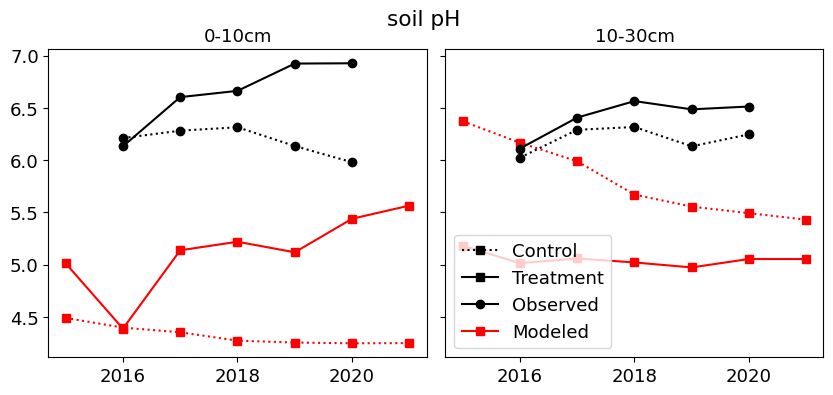

In [5]:
fig, axes = plt.subplots(1, 2, figsize = (10, 4), sharex = True, sharey = True)
fig.subplots_adjust(wspace = 0.05)
for i, (depth, ax) in enumerate(zip(depth_names, axes.flat)):

    ax.plot(tvec, soil_pH['control'][depth], ':sr')
    ax.plot(tvec, soil_pH['treatment'][depth], '-sr')

    ax.plot(obs_soil_pH.index, obs_soil_pH[(depth, 'control')], ':ok')
    ax.plot(obs_soil_pH.index, obs_soil_pH[(depth, 'treatment')], '-ok')

    ax.set_title(depth)
ax.plot(np.nan, np.nan, ':sk', label = 'Control')
ax.plot(np.nan, np.nan, '-sk', label = 'Treatment')
ax.plot(np.nan, np.nan, '-ok', label = 'Observed')
ax.plot(np.nan, np.nan, '-sr', label = 'Modeled')
ax.legend()
fig.suptitle('soil pH')

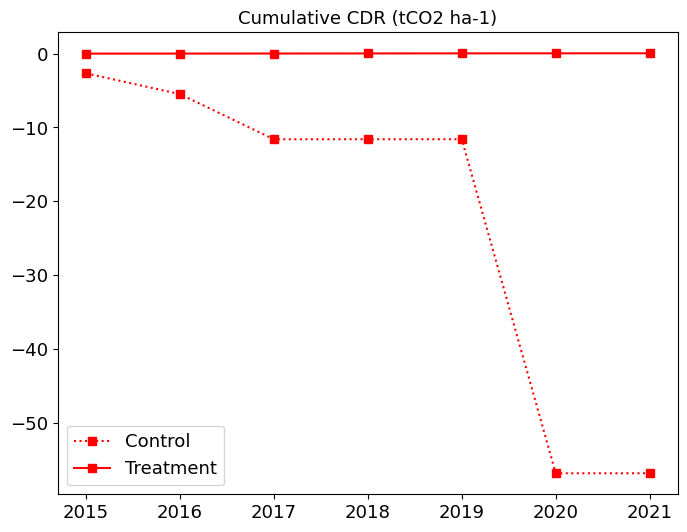

In [6]:
fig, ax = plt.subplots(figsize = (8, 6), sharex = True, sharey = True)
ax.plot(tvec, r_sequestration['control'], ':sr', label = 'Control')
ax.plot(tvec, r_sequestration['treatment'], '-sr', label = 'Treatment')
ax.set_title('Cumulative CDR (tCO2 ha-1)')
ax.legend()

Text(0.5, 0.98, 'Cation exchange capacity')

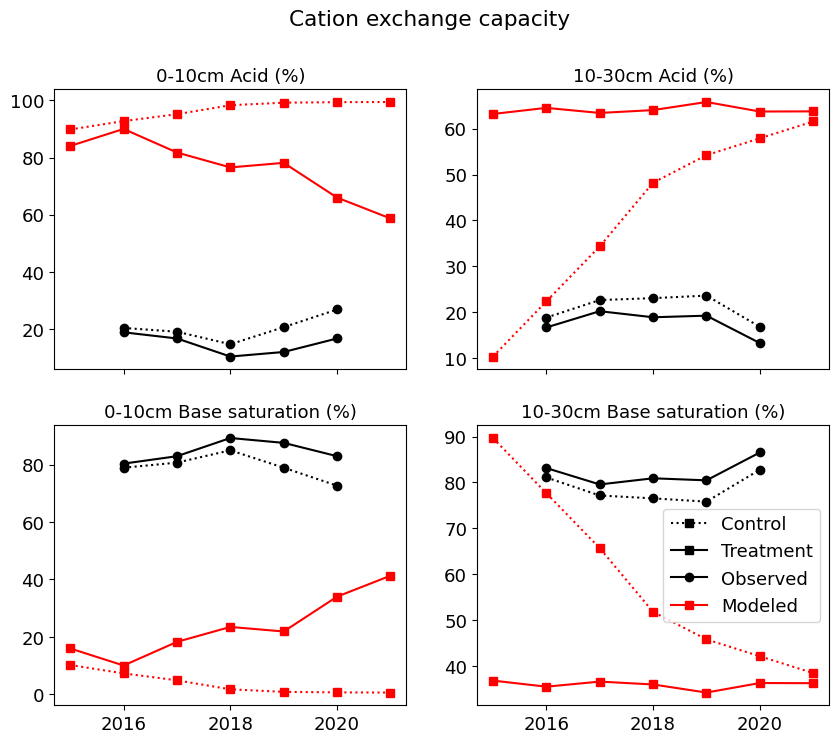

In [7]:
fig, axes = plt.subplots(2, 2, sharex = True, figsize = (10, 8))
for i, dname in enumerate(depth_names):
    ax = axes[0, i]

    ax.plot(pct_acid['control'].index, pct_acid['control'][dname]*100, ':sr')
    ax.plot(pct_acid['treatment'].index, pct_acid['treatment'][dname]*100, '-sr')

    ax.plot(cec_pct.index, cec_pct[('acid', dname,'control')], ':ok')
    ax.plot(cec_pct.index, cec_pct[('acid', dname,'treatment')], '-ok')

    #ax.set_ylim([0, 50])
    ax.set_title(dname + ' Acid (%)')

    ax = axes[1, i]

    ax.plot(base_saturation['control'].index, base_saturation['control'][dname]*100, ':sr')
    ax.plot(base_saturation['treatment'].index, base_saturation['treatment'][dname]*100, '-sr')

    ax.plot(cec_pct.index, cec_pct[('base sat', dname,'control')], ':ok')
    ax.plot(cec_pct.index, cec_pct[('base sat', dname,'treatment')], '-ok')

    #ax.set_ylim([50, 100])
    ax.set_title(dname + ' Base saturation (%)')

ax.plot(np.nan, np.nan, ':sk', label = 'Control')
ax.plot(np.nan, np.nan, '-sk', label = 'Treatment')
ax.plot(np.nan, np.nan, '-ok', label = 'Observed')
ax.plot(np.nan, np.nan, '-sr', label = 'Modeled')
ax.legend()
fig.suptitle('Cation exchange capacity')

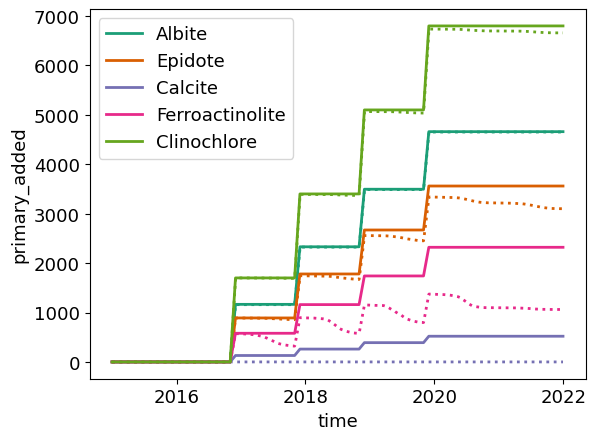

In [8]:
# Dissolved amount of individual minerals
for m,(id,mineral,color) in enumerate(
    zip([2,4,5,6,7], ['Albite','Epidote','Calcite','Ferroactinolite', 'Clinochlore'],
        ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e'])
):
    hr['primary_mineral'][:, id, 0].plot(ls = ':', lw = 2, color = color)
    (hr['primary_added'][:, id, 0].cumsum() * 86400).plot(label = mineral, ls = '-', lw = 2, color = color)
plt.legend()

Text(0.5, 0.98, 'Cation loss from weathering')

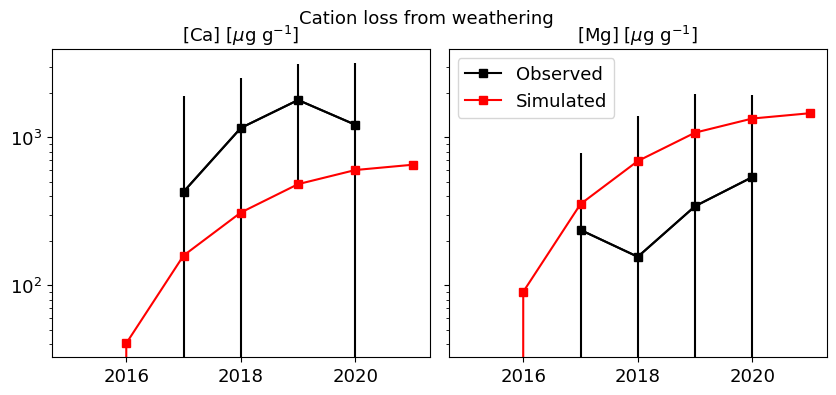

In [9]:
fig, axes = plt.subplots(1, 2, sharex = True, figsize = (10, 4), sharey = True)
fig.subplots_adjust(wspace = 0.05)
ax = axes.flat[0]
ax.plot(weathering_difference.index, 
        weathering_difference['Ca weathered'], '-sk', label = 'Observed')
ax.errorbar(x = weathering_difference.index, y = weathering_difference['Ca weathered'], 
            yerr = weathering_difference['stdev.1'], ecolor = 'k', color = 'k')
ax.plot(tvec, total_dissolved_ca, '-sr', label = 'Simulated')
ax.set_title('[Ca] [$\mu$g g$^{-1}$]')

ax = axes.flat[1]
ax.plot(weathering_difference.index, 
        weathering_difference['Mg weathered'], '-sk', label = 'Observed')
ax.errorbar(x = weathering_difference.index, y = weathering_difference['Mg weathered'], 
            yerr = weathering_difference['stdev.2'], ecolor = 'k', color = 'k')
ax.plot(tvec, total_dissolved_mg, '-sr', label = 'Simulated')
ax.legend(loc = 'upper left')
ax.set_title('[Mg] [$\mu$g g$^{-1}$]')

ax.set_yscale('log')

fig.suptitle('Cation loss from weathering', fontsize = 'medium')

In [10]:
# Check if pore water saturation is too high and inhibiting the reaction

In [11]:
hr.close()